In [7]:
import torch
import torch.nn as nn           # Sinir ağı katmanları için
import torch.optim as optim     # Optimizasyon (öğrenme) algoritmaları için
from torchvision import datasets, transforms # Hazır veri setleri ve dönüşümler
from torch.utils.data import DataLoader      # Veriyi küçük paketler (batch) halinde sunmak için
import matplotlib.pyplot as plt # Görselleştirme için

print("PyTorch sürümü:", torch.__version__)

PyTorch sürümü: 2.10.0+cpu


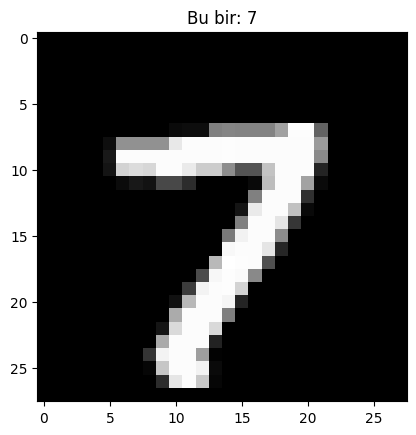

In [8]:
# Veriyi standardize ediyoruz (0-1 arasına çekiyoruz)
transform = transforms.Compose([transforms.ToTensor()])

# Eğitim verisini indir
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Veriyi 64'erli paketler (batch) halinde modele verecek olan yükleyici
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

# Bir örneğe bakalım
images, labels = next(iter(train_loader))
plt.imshow(images[0].numpy().squeeze(), cmap='gray')
plt.title(f"Bu bir: {labels[0].item()}")
plt.show()

In [9]:
class BasitModel(nn.Module):
    def __init__(self):
        super(BasitModel, self).__init__()
        self.flatten = nn.Flatten() # 28x28 -> 784
        self.katman1 = nn.Linear(784, 128) # Giriş: 784, Gizli: 128 nöron
        self.aktivasyon = nn.ReLU()       # Negatif değerleri sıfırlayan fonksiyon
        self.katman2 = nn.Linear(128, 10)  # Çıkış: 10 (0-9 arası rakamlar)

    def forward(self, x):
        x = self.flatten(x)
        x = self.katman1(x)
        x = self.aktivasyon(x)
        x = self.katman2(x)
        return x

model = BasitModel()
print("Model Yapısı:\n", model)

Model Yapısı:
 BasitModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (katman1): Linear(in_features=784, out_features=128, bias=True)
  (aktivasyon): ReLU()
  (katman2): Linear(in_features=128, out_features=10, bias=True)
)


In [10]:
# Hata ölçer: Çok sınıflı sınıflandırma için standarttır
criterion = nn.CrossEntropyLoss() 

# Güncelleyici: Adam, en popüler ve hızlı öğrenen optimizasyon algoritmasıdır
# lr=0.001 (Learning Rate): Modelin her adımda ne kadar büyük bir düzeltme yapacağı
optimizer = optim.Adam(model.parameters(), lr=0.001) 

print("Hata ölçer ve optimizer tanımlandı.")

Hata ölçer ve optimizer tanımlandı.


In [11]:
epochs = 3 # Veri setini kaç kez hatmetmek istiyoruz?

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        # 1. Gradyanları (hafızayı) sıfırla
        optimizer.zero_grad()
        
        # 2. İleri Besleme (Forward Pass): Model tahmin yapsın
        outputs = model(images)
        
        # 3. Hatayı Hesapla (Loss): Tahmin ile gerçek etiket arasındaki fark
        loss = criterion(outputs, labels)
        
        # 4. Geri Yayılım (Backpropagation): Hatayı geriye doğru ilet
        loss.backward()
        
        # 5. Ağırlıkları Güncelle: Usta (Optimizer) hatayı düzeltsin
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1} tamamlandı. Ortalama Kayıp (Loss): {running_loss/len(train_loader):.4f}")

print("Eğitim Bitti! Artık modelimiz rakamları tanıyabiliyor.")

Epoch 1 tamamlandı. Ortalama Kayıp (Loss): 0.3495
Epoch 2 tamamlandı. Ortalama Kayıp (Loss): 0.1557
Epoch 3 tamamlandı. Ortalama Kayıp (Loss): 0.1088
Eğitim Bitti! Artık modelimiz rakamları tanıyabiliyor.


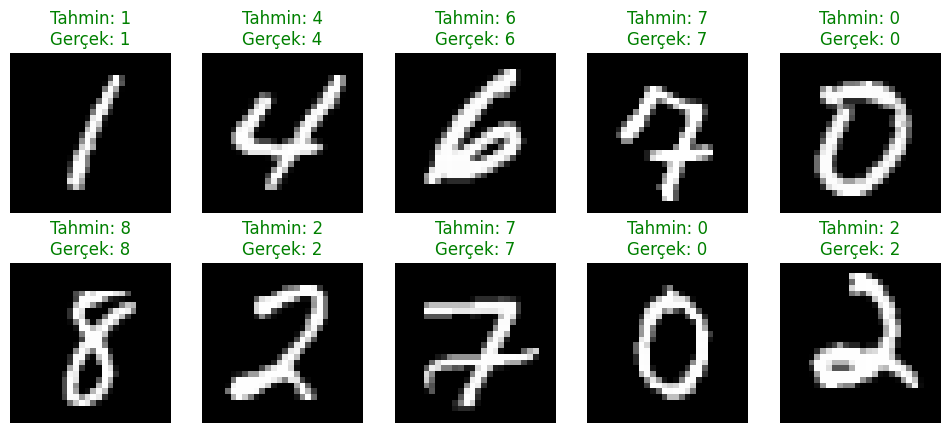

In [12]:
# Test veri setini indiriyoruz
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)
test_loader = DataLoader(dataset=test_dataset, batch_size=10, shuffle=True)

# Test moduna geçiyoruz (bazı katmanlar eğitimde farklı çalışır)
model.eval()

# Rastgele 10 tane test resmi alalım
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Tahmin yapalım
with torch.no_grad(): # Test sırasında gradyan hesaplamaya gerek yok, hafıza tasarrufu sağlar
    outputs = model(images)
    _, predicted = torch.max(outputs, 1) # En yüksek skorlu tahmini seç

# Sonuçları görselleştirelim
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].numpy().squeeze(), cmap='gray')
    color = 'green' if predicted[i] == labels[i] else 'red'
    plt.title(f"Tahmin: {predicted[i]}\nGerçek: {labels[i]}", color=color)
    plt.axis('off')
plt.show()

In [13]:
class GelismisCNN(nn.Module):
    def __init__(self):
        super(GelismisCNN, self).__init__()
        # 1. Katman: Resmi tarayıp özellikleri çıkaran Convolution
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        # 2. Katman: Boyutu yarıya indiren Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 3. Katman: Daha derin özellikler için ikinci Conv
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        
        # Son aşama: Özellikleri toplayıp sınıflandırma yapma
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128) # Resim 28x28 -> 14x14 -> 7x7 oldu
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Yeni modeli oluştur
cnn_model = GelismisCNN()
print(cnn_model)

GelismisCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [14]:
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

for epoch in range(2): # CNN çok hızlı öğrendiği için 2 epoch bile yetebilir
    for images, labels in train_loader:
        optimizer_cnn.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_cnn.step()
    print(f"CNN Epoch {epoch+1} bitti. Kayıp: {loss.item():.4f}")

CNN Epoch 1 bitti. Kayıp: 0.1159
CNN Epoch 2 bitti. Kayıp: 0.1659


In [15]:
# Modelin ağırlıklarını 'mnist_cnn.pth' adıyla kaydediyoruz
torch.save(cnn_model.state_dict(), 'mnist_cnn.pth')
print("Model başarıyla kaydedildi! Dosya gezgininde 'mnist_cnn.pth' dosyasını görebilirsin.")

Model başarıyla kaydedildi! Dosya gezgininde 'mnist_cnn.pth' dosyasını görebilirsin.


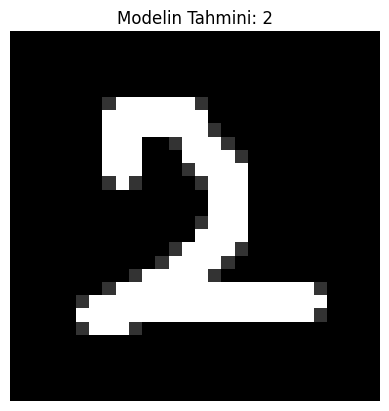

In [16]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

def tahmin_et(resim_yolu):
    # 1. Resmi aç ve siyah-beyaza çevir
    img = Image.open(resim_yolu).convert('L')
    
    # 2. Boyutu 28x28 yap (Eğer Paint'te zaten öyle yaptıysan bu satır sadece emin olur)
    img = img.resize((28, 28))
    
    # 3. Modele uygun formata (Tensor) sok
    # Eğitimde kullandığımız transformun aynısı
    transform = transforms.Compose([transforms.ToTensor()])
    img_tensor = transform(img)
    img_tensor = img_tensor.unsqueeze(0) # Batch boyutu ekle: [1, 1, 28, 28]

    # 4. Tahmin yap
    cnn_model.eval()
    with torch.no_grad():
        output = cnn_model(img_tensor)
        tahmin = torch.max(output, 1)[1].item()
    
    # 5. Görselleştir
    plt.imshow(img, cmap='gray')
    plt.title(f"Modelin Tahmini: {tahmin}")
    plt.axis('off')
    plt.show()

# Tahmini başlat!
tahmin_et('deneme_rakam.png')